Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - loss: 0.0124 - val_loss: 4.3992e-04
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - loss: 4.4398e-04 - val_loss: 4.1562e-04
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - loss: 4.2052e-04 - val_loss: 4.1002e-04
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - loss: 4.1680e-04 - val_loss: 4.0568e-04
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - loss: 4.1431e-04 - val_loss: 4.0824e-04
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


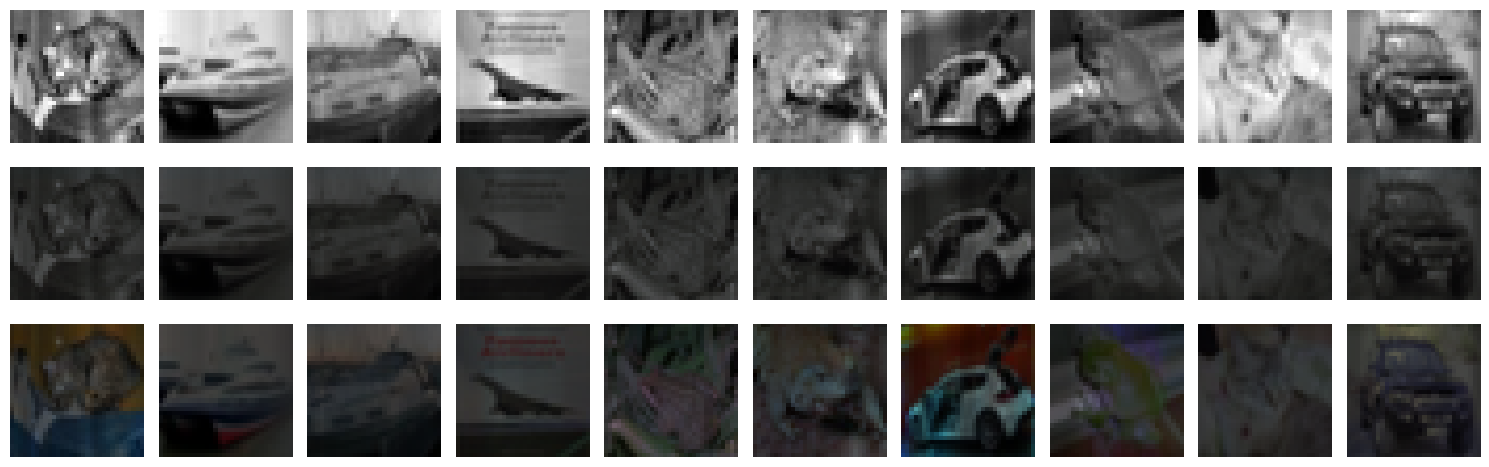

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import normalize

# Load CIFAR-10 dataset
(x_train, _), (x_test, _) = cifar10.load_data()

# Convert images to grayscale
def rgb_to_gray(images):
    return np.dot(images[..., :3], [0.299, 0.587, 0.114])

x_train_gray = rgb_to_gray(x_train).astype("float32")
x_test_gray = rgb_to_gray(x_test).astype("float32")

# Normalize data to [0, 1]
x_train = normalize(x_train, axis=1)
x_test = normalize(x_test, axis=1)
x_train_gray = normalize(x_train_gray[..., np.newaxis], axis=1)
x_test_gray = normalize(x_test_gray[..., np.newaxis], axis=1)

# Build a simple colorization model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 1)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(3, (3, 3), activation='sigmoid', padding='same')  # Predict 3 channels (RGB)
])

model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(x_train_gray, x_train, epochs=5, batch_size=64, validation_data=(x_test_gray, x_test))

# Test the model
predicted = model.predict(x_test_gray[:10])

# Visualize results
fig, axes = plt.subplots(3, 10, figsize=(15, 5))

for i in range(10):
    # Original grayscale image
    axes[0, i].imshow(x_test_gray[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    # Predicted color image
    axes[1, i].imshow(predicted[i])
    axes[1, i].axis('off')
    # Original color image
    axes[2, i].imshow(x_test[i])
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Grayscale')
axes[1, 0].set_ylabel('Predicted')
axes[2, 0].set_ylabel('Original')

plt.tight_layout()
plt.show()


In [7]:
from tensorflow.keras.losses import MeanSquaredError

# Use the proper loss function object
model.compile(optimizer='adam', loss=MeanSquaredError())


In [8]:
# Save the model to a file
model.save("colorization_model.h5")
print("Model saved successfully!")


Model saved successfully!


In [9]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model("colorization_model.h5")
print("Model loaded successfully!")


Model loaded successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


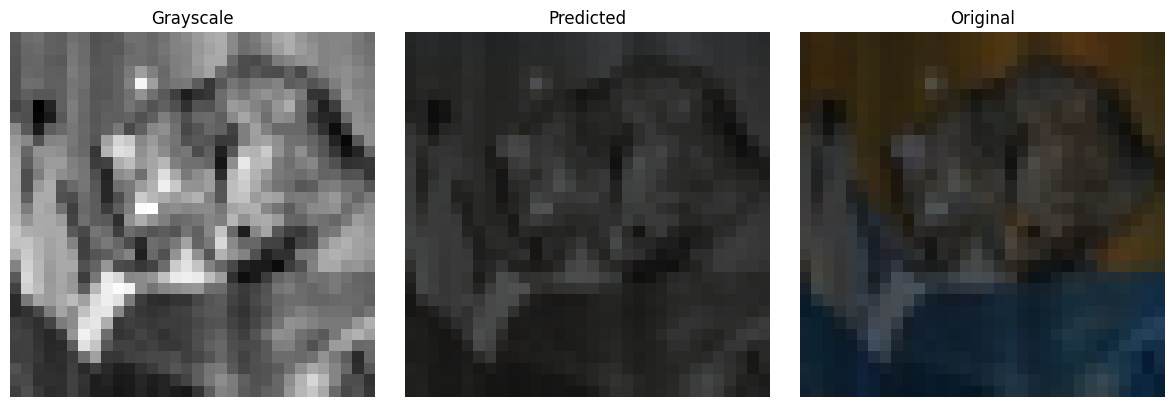

In [10]:
import matplotlib.pyplot as plt

# Select a single test image
test_image_gray = x_test_gray[0:1]  # Grayscale version of the first test image
test_image_original = x_test[0]    # Original RGB version of the same test image

# Predict the colorized image
predicted_image = loaded_model.predict(test_image_gray)

# Visualize the results
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Grayscale image
axes[0].imshow(test_image_gray.squeeze(), cmap='gray')
axes[0].set_title("Grayscale")
axes[0].axis('off')

# Predicted color image
axes[1].imshow(predicted_image[0])
axes[1].set_title("Predicted")
axes[1].axis('off')

# Original color image
axes[2].imshow(test_image_original)
axes[2].set_title("Original")
axes[2].axis('off')

plt.tight_layout()
plt.show()
